<a href="https://colab.research.google.com/github/sri-nikesh-1432/Customer-Churn-Analysis/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
# --- STEP 1: Generate Behavioral Data ---
# Creating a dataset that mimics real user behavior (engagement vs churn)
np.random.seed(42)
num_users = 500

data = {
    'UserID': range(1, num_users + 1),
    'MonthlyLogins': np.random.randint(1, 30, num_users),
    'SupportCalls': np.random.randint(0, 10, num_users),
    'SubscriptionPlan': np.random.choice(['Basic', 'Premium', 'Pro'], num_users),
    'MonthlyCharge': np.random.uniform(10, 100, num_users),
    'EngagementScore': np.random.uniform(0, 100, num_users),
}

df = pd.DataFrame(data)

# Logic: Users with low engagement and high support calls are more likely to churn
df['Churn'] = ((df['EngagementScore'] < 30) | (df['SupportCalls'] > 6)).astype(int)

print("### CUSTOMER DATA PREVIEW ###")
display(df.head())

### CUSTOMER DATA PREVIEW ###


,UserID,MonthlyLogins,SupportCalls,SubscriptionPlan,MonthlyCharge,EngagementScore,Churn
0,1,7,1,Pro,95.521362,37.978578,0
1,2,20,1,Premium,50.140520,86.333365,0
2,3,29,6,Premium,26.661964,51.908179,0
3,4,15,5,Pro,58.771085,47.918188,0
4,5,11,2,Pro,88.565125,2.564207,1



### CHURN PATTERN ANALYSIS ###


/tmp/ipykernel_2967/490054621.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Churn', y='SupportCalls', data=df, palette='coolwarm')
/tmp/ipykernel_2967/490054621.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='EngagementScore', data=df, palette='Set2')


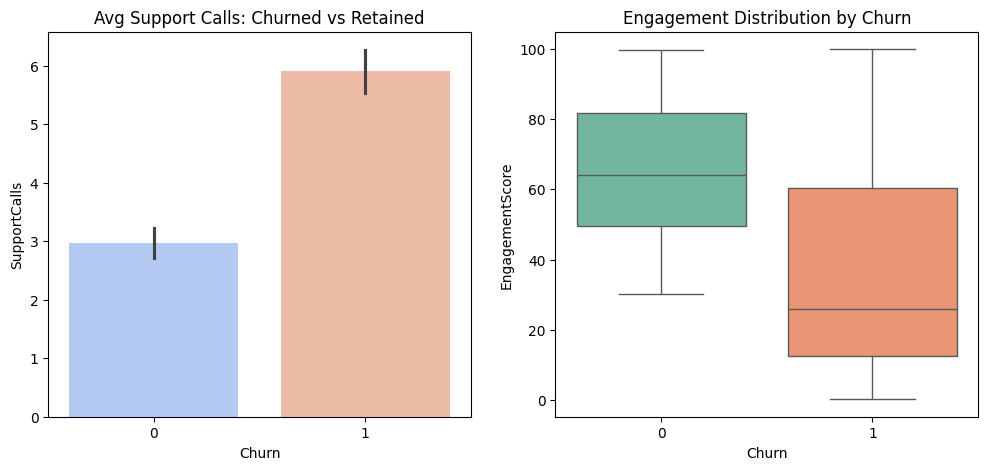

In [4]:
# --- STEP 2: Exploratory Data Analysis (EDA) ---
print("\n### CHURN PATTERN ANALYSIS ###")

# 1. Churn vs. Support Calls
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x='Churn', y='SupportCalls', data=df, palette='coolwarm')
plt.title('Avg Support Calls: Churned vs Retained')

# 2. Churn vs. Engagement
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='EngagementScore', data=df, palette='Set2')
plt.title('Engagement Distribution by Churn')
plt.show()

In [5]:
# --- STEP 3: Identifying Key Factors ---
# We use numeric_only=True to tell Pandas to ignore the text columns like 'SubscriptionPlan'
correlation = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

print("\n### CORRELATION WITH CHURN ###")
print(correlation)


# --- STEP 4: Strategy Suggestions ---
def suggest_improvements(df):
    high_risk = df[(df['Churn'] == 1) & (df['SupportCalls'] > 5)]
    print(f"\nREMARKS: {len(high_risk)} users are 'High Risk' due to excessive support calls.")
    print("SUGGESTION: Improve onboarding tutorials to reduce support dependency.")

suggest_improvements(df)


### CORRELATION WITH CHURN ###
Churn              1.000000
SupportCalls       0.499088
UserID             0.006689
MonthlyLogins      0.004727
MonthlyCharge     -0.084452
EngagementScore   -0.506779
Name: Churn, dtype: float64

REMARKS: 164 users are 'High Risk' due to excessive support calls.
SUGGESTION: Improve onboarding tutorials to reduce support dependency.
